# 03 Demand Analysis

## Goal
Explore grocery demand patterns by hour, day of week, and department.

## Input
`data/processed_demand_data.csv`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
demand_data = pd.read_csv("/Users/ayu/Desktop/AI_Grocery_Demand_Forecasting/notebooks/data/processed_demand_data.csv")
demand_data.head()

,day_of_week,hour,dept_name,demand,is_weekend,hour_sin,hour_cos,dept_encoded,log_demand
0,0,0,alcohol,52,1,0.0,1.0,0,3.970292
1,0,0,babies,400,1,0.0,1.0,1,5.993961
2,0,0,bakery,1301,1,0.0,1.0,2,7.171657
3,0,0,beverages,2970,1,0.0,1.0,3,7.996654
4,0,0,breakfast,721,1,0.0,1.0,4,6.582025


## 1. Demand by Hour

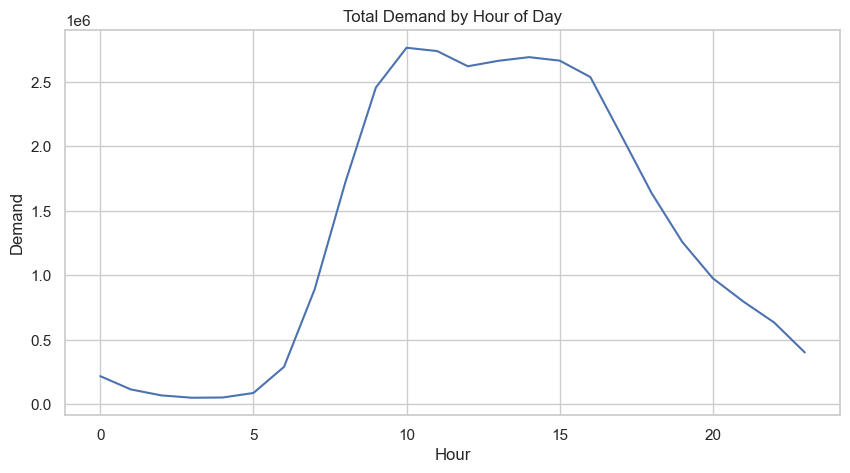

In [3]:
hourly_demand = demand_data.groupby('hour')['demand'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_demand, x='hour', y='demand')
plt.title("Total Demand by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Demand")
plt.show()

## 2. Demand by Day of Week

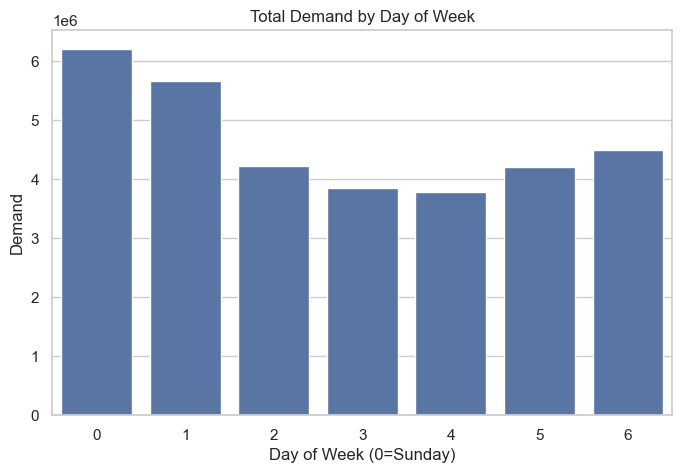

In [4]:
daily_demand = demand_data.groupby('day_of_week')['demand'].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=daily_demand, x='day_of_week', y='demand')
plt.title("Total Demand by Day of Week")
plt.xlabel("Day of Week (0=Sunday)")
plt.ylabel("Demand")
plt.show()

## 3. Top Departments by Total Demand

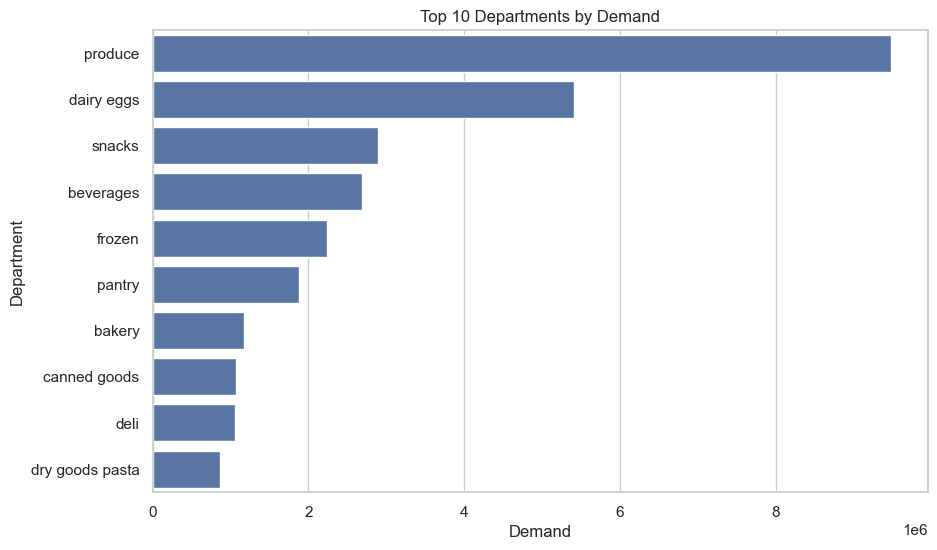

In [5]:
dept_demand = (
    demand_data.groupby('dept_name')['demand']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=dept_demand, x='demand', y='dept_name')
plt.title("Top 10 Departments by Demand")
plt.xlabel("Demand")
plt.ylabel("Department")
plt.show()

## 4. Department Demand Heatmap
Average demand by department and hour.

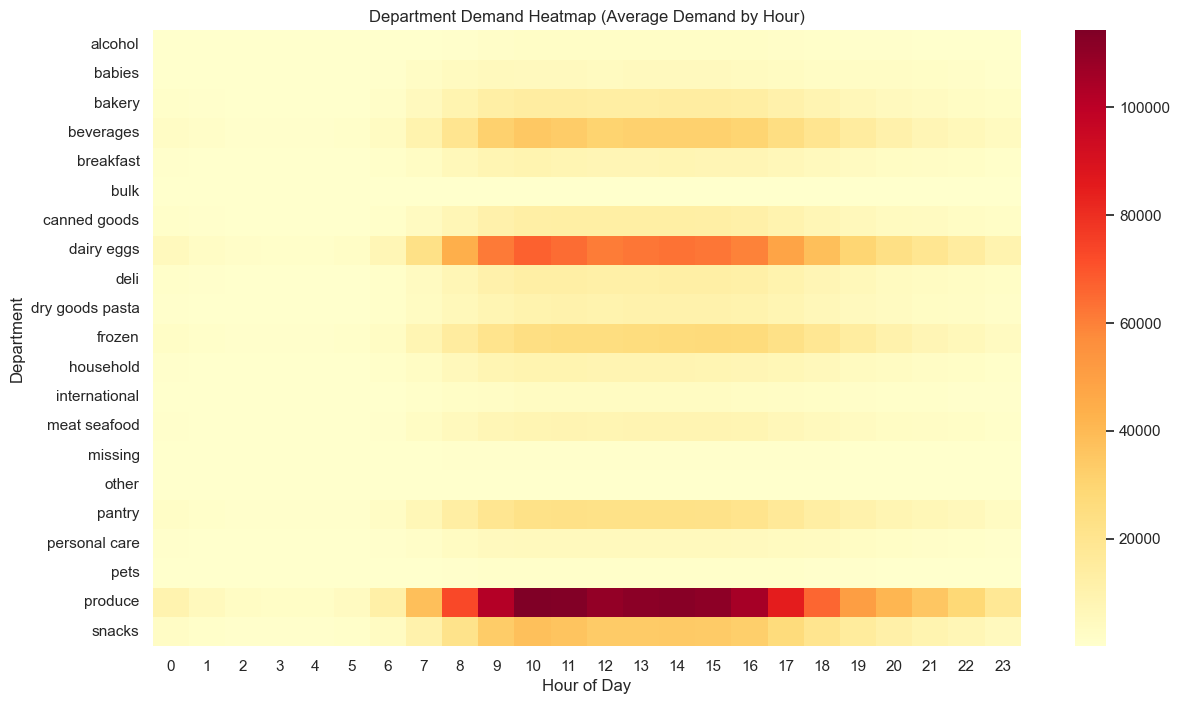

In [6]:
heatmap_data = demand_data.pivot_table(
    values='demand',
    index='dept_name',
    columns='hour',
    aggfunc='mean'
)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap="YlOrRd")
plt.title("Department Demand Heatmap (Average Demand by Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Department")
plt.show()

## Key Insights
- Demand peaks during late morning to early afternoon.
- Produce and dairy eggs are the highest-demand departments.
- Overnight demand is very low across all departments.
- Department and hour are the strongest demand pattern drivers.